In [1]:
import sys
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt

sys.path.append("../src")
import tensorflow_wavelets.Layers.DWT as DWT


In [2]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension: (batch, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [3]:
nb_classes = 10
image_size = (28, 28)
epochs = 30
batch_size = 32

In [4]:
model = keras.Sequential()
model.add(keras.Input(shape=(*image_size, 1)))
model.add(DWT.DWT(name="haar", concat=0))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(nb_classes, activation="softmax"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 haar (DWT)                  (None, 14, 14, 4)         0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 10)                7850      
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_test, y_test)
)

Epoch 1/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.5231 - accuracy: 0.8664 - val_loss: 0.3281 - val_accuracy: 0.9136
Epoch 2/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3179 - accuracy: 0.9121 - val_loss: 0.2929 - val_accuracy: 0.9182
Epoch 3/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2910 - accuracy: 0.9184 - val_loss: 0.2809 - val_accuracy: 0.9207
Epoch 4/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2787 - accuracy: 0.9220 - val_loss: 0.2739 - val_accuracy: 0.9236
Epoch 5/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2701 - accuracy: 0.9249 - val_loss: 0.2780 - val_accuracy: 0.9227
Epoch 6/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2642 - accuracy: 0.9261 - val_loss: 0.2740 - val_accuracy: 0.9237
Epoch 7/30
1875/1875 [==============================] - 3s 2ms/step - loss: 0.2596 - accuracy: 0.9276 - val_loss: 0.2708 - val_accuracy:

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


313/313 [==============================] - 0s 1ms/step - loss: 0.2745 - accuracy: 0.9251
Test Accuracy: 0.9251


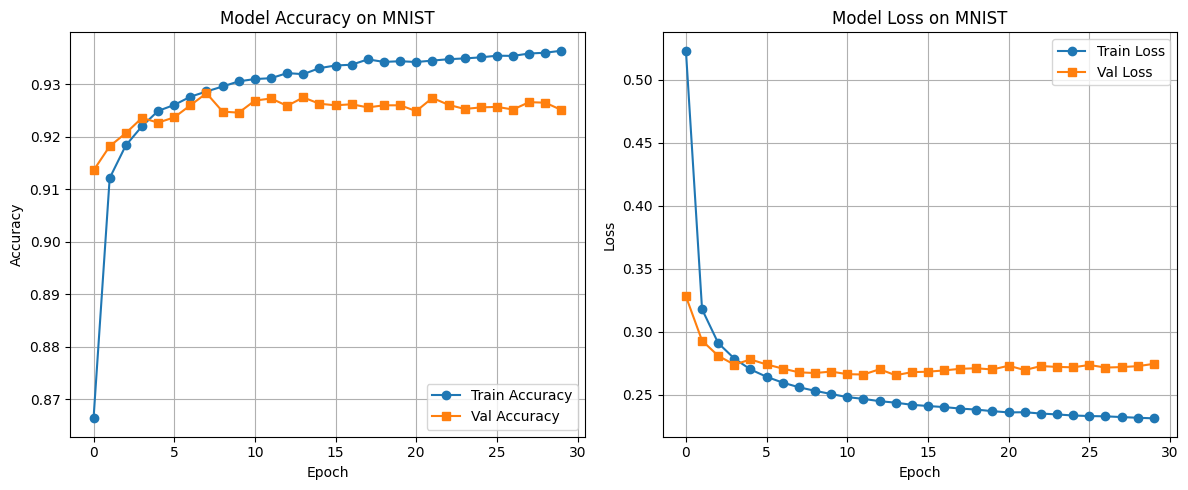

In [7]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
plt.title('Model Accuracy on MNIST')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='s')
plt.title('Model Loss on MNIST')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

